# 02 · Sentiment Analysis on Justifications

Applies two complementary sentiment analyzers to annotator justifications:
- **VADER** (rule-based, fast, lexicon-driven)
- **CardiffNLP RoBERTa** (`cardiffnlp/twitter-roberta-base-sentiment-latest`) — transformer-based

**Research question**: Do the *expressed* sentiment in justifications align with the *predicted* sentiment label assigned by the persona? Do patterns vary across persona groups?

> This analysis was motivated by Prof. Dan's observation that cosine-similarity results showed the highest variance, and sentiment in justifications was a candidate explanation.

In [1]:
import sys
import json
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm

from src.config import FIGURES, OUTPUTS, FONT_SCALE, SENT_COLORS, SENT_COLORS_3, NP_THINK_PATH, NP_NOTHINK_PATH
from src.data_loading import load_annotations, parse_demographics, create_profiles
from src.sentiment import analyze_vader, analyze_roberta, agreement_metrics, agreement_with_predicted

MUTED = sns.color_palette("muted")
sns.set_theme(style="whitegrid", font_scale=FONT_SCALE)
plt.rcParams["figure.dpi"] = 150

FIGURES.mkdir(exist_ok=True)
OUTPUTS.mkdir(exist_ok=True)

df = load_annotations()
df = parse_demographics(df)
df = create_profiles(df)
print(f"Records: {len(df):,} | Images: {df['image_id'].nunique():,} | Personas: {df['persona_id'].nunique():,}")

Records: 59,708 | Images: 50 | Personas: 1,200


## 1 · VADER sentiment on justifications

In [2]:
vader_df = analyze_vader(df["justification"].tolist())
df["vader_compound"] = vader_df["compound"].values
df["vader_label"]    = vader_df["vader_label"].values
print(df["vader_label"].value_counts())

vader_label
Negative    31577
Positive    26203
Neutral      1928
Name: count, dtype: int64


## 2 · Agreement: VADER label vs. predicted sentiment label

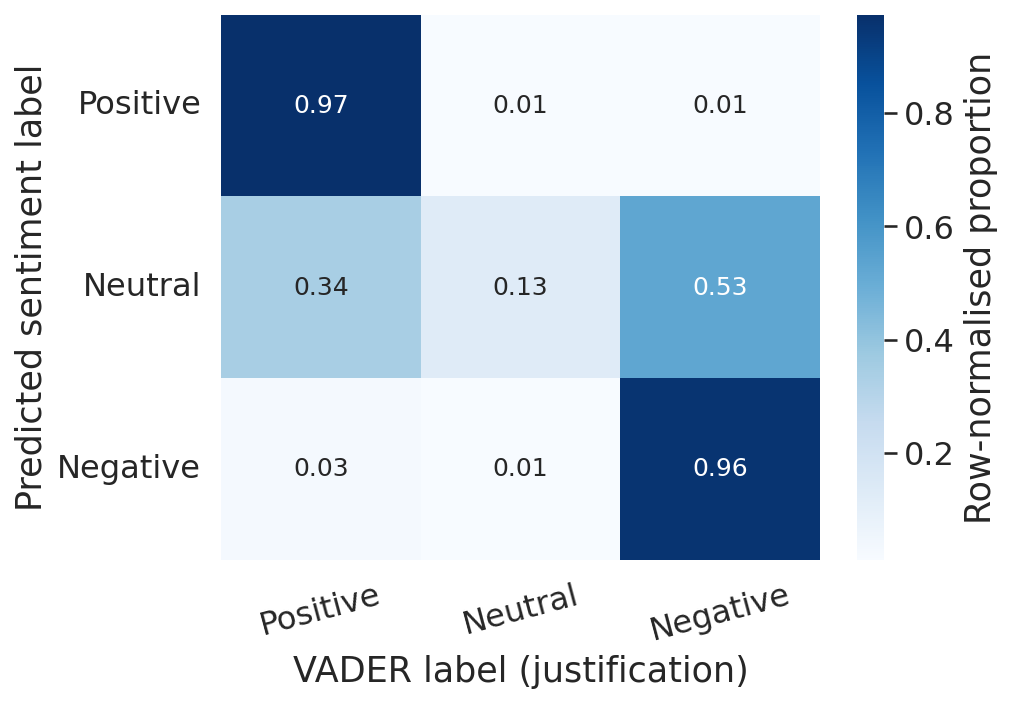

              precision    recall  f1-score   support

    Positive      0.864     0.958     0.909     25604
     Neutral      0.570     0.129     0.210      6857
    Negative      0.868     0.974     0.918     20576

    accuracy                          0.857     53037
   macro avg      0.767     0.687     0.679     53037
weighted avg      0.827     0.857     0.822     53037



In [3]:
from sklearn.metrics import confusion_matrix, classification_report

label_order = ["Positive", "Neutral", "Negative"]
subset = df[df["predicted_sentiment"].isin(label_order) & df["vader_label"].isin(label_order)]

cm = confusion_matrix(subset["predicted_sentiment"], subset["vader_label"], labels=label_order)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm_norm, annot=True, fmt=".2f", xticklabels=label_order, yticklabels=label_order,
    cmap="Blues", ax=ax, cbar_kws={"label": "Row-normalised proportion"},
    annot_kws={"size": 12},
)
ax.set_xlabel("VADER label (justification)")
ax.set_ylabel("Predicted sentiment label")
# ax.set_title("VADER agreement with predicted sentiment")
ax.tick_params(axis="x", rotation=15)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
fig.savefig(FIGURES / "fig_sentiment_vader_agreement.pdf")
fig.savefig(FIGURES / "fig_sentiment_vader_agreement.png")
plt.show()

print(classification_report(subset["predicted_sentiment"], subset["vader_label"],
                             target_names=label_order, digits=3))


## 3 · VADER compound score distribution by predicted sentiment

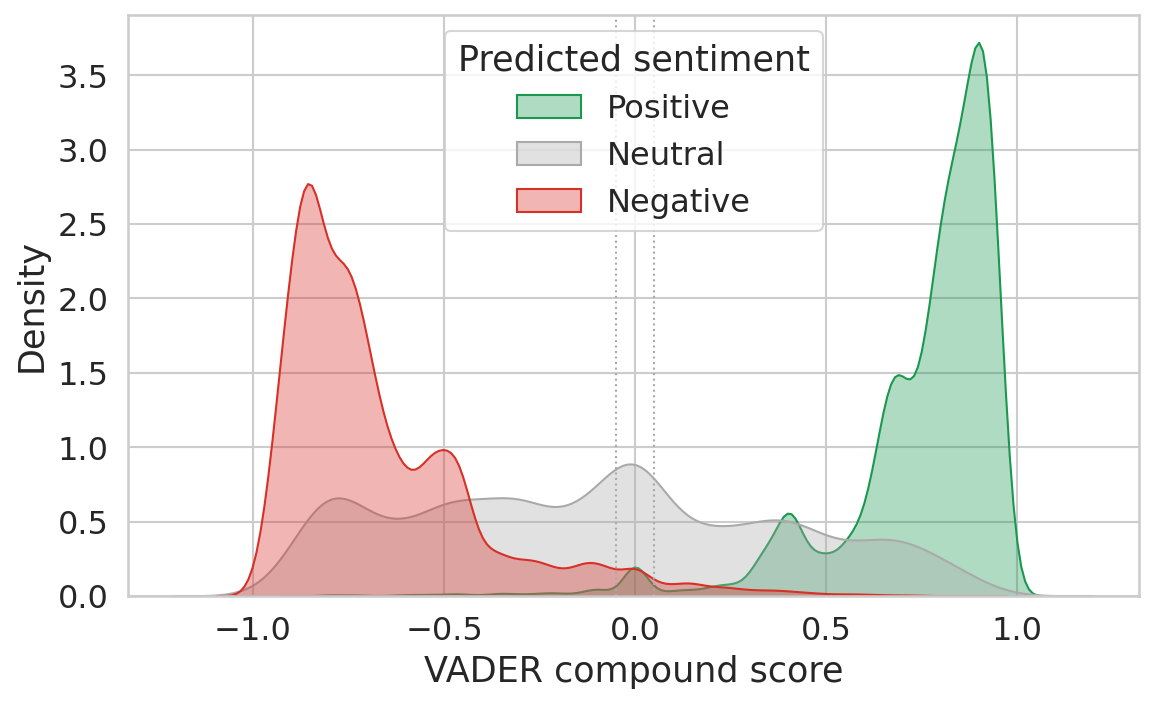

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

for label in label_order:
    sub = df[df["predicted_sentiment"] == label]["vader_compound"]
    sns.kdeplot(sub, label=label, fill=True, alpha=0.35,
                color=SENT_COLORS_3[label], ax=ax)

ax.axvline(0.05,  color="#aaaaaa", linestyle=":", linewidth=1)
ax.axvline(-0.05, color="#aaaaaa", linestyle=":", linewidth=1)
ax.set_xlabel("VADER compound score")
ax.set_ylabel("Density")
# ax.set_title("VADER compound by predicted sentiment label")
ax.legend(title="Predicted sentiment")
plt.tight_layout()
fig.savefig(FIGURES / "fig_sentiment_vader_compound_kde.pdf")
fig.savefig(FIGURES / "fig_sentiment_vader_compound_kde.png")
plt.show()


## 4 · RoBERTa-based sentiment (CardiffNLP)

Requires `transformers` and internet access on first run to download model weights.

In [5]:
ROBERTA_CACHE = OUTPUTS / "roberta_justifications.csv"

roberta_df = analyze_roberta(df["justification"].tolist(), cache_path=ROBERTA_CACHE)
df["roberta_label"] = roberta_df["roberta_label"].values
df["roberta_score"] = roberta_df["roberta_score"].values
print(df["roberta_label"].value_counts())

roberta_label
Negative    30146
Positive    23187
Neutral      6375
Name: count, dtype: int64


## 5 · Agreement: RoBERTa vs. predicted sentiment

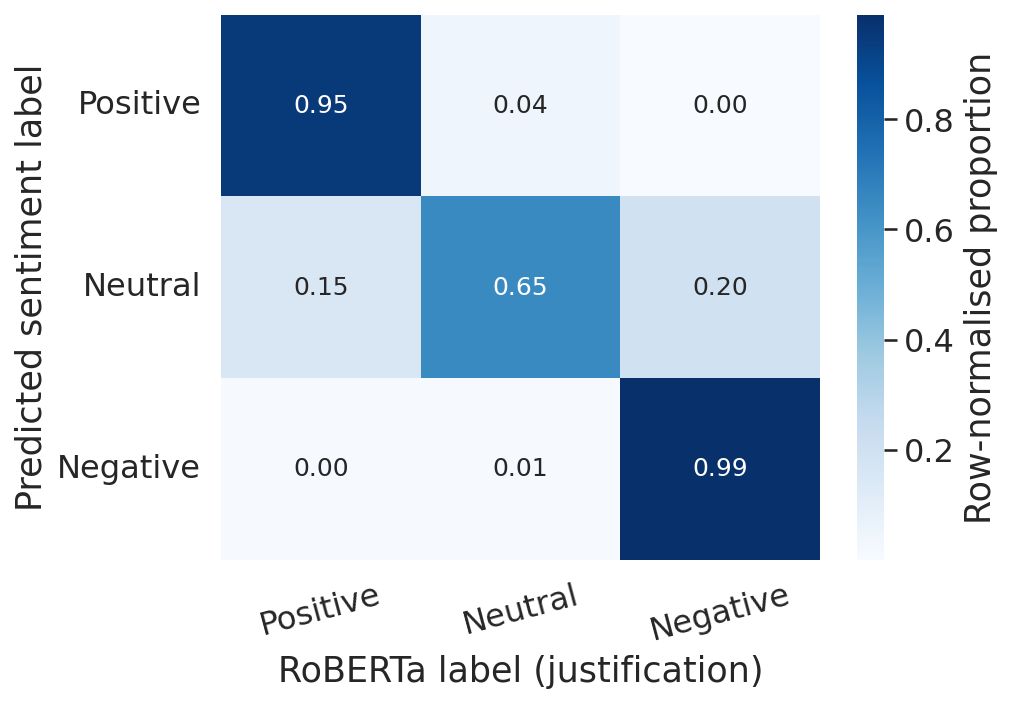

              precision    recall  f1-score   support

    Positive      0.948     0.990     0.968     25604
     Neutral      0.810     0.648     0.720      6857
    Negative      0.944     0.955     0.949     20576

    accuracy                          0.932     53037
   macro avg      0.900     0.864     0.879     53037
weighted avg      0.928     0.932     0.929     53037



In [6]:
subset2 = df[df["predicted_sentiment"].isin(label_order) & df["roberta_label"].isin(label_order)]

cm2 = confusion_matrix(subset2["predicted_sentiment"], subset2["roberta_label"], labels=label_order)
cm2_norm = cm2.astype(float) / cm2.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm2_norm, annot=True, fmt=".2f", xticklabels=label_order, yticklabels=label_order,
    cmap="Blues", ax=ax, cbar_kws={"label": "Row-normalised proportion"},
    annot_kws={"size": 12},
)
ax.set_xlabel("RoBERTa label (justification)")
ax.set_ylabel("Predicted sentiment label")
# ax.set_title("RoBERTa agreement with predicted sentiment")
ax.tick_params(axis="x", rotation=15)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
fig.savefig(FIGURES / "fig_sentiment_roberta_agreement.pdf")
fig.savefig(FIGURES / "fig_sentiment_roberta_agreement.png")
plt.show()

print(classification_report(subset2["predicted_sentiment"], subset2["roberta_label"],
                             target_names=label_order, digits=3))


## 6 · Sentiment in justifications per persona group (VADER)

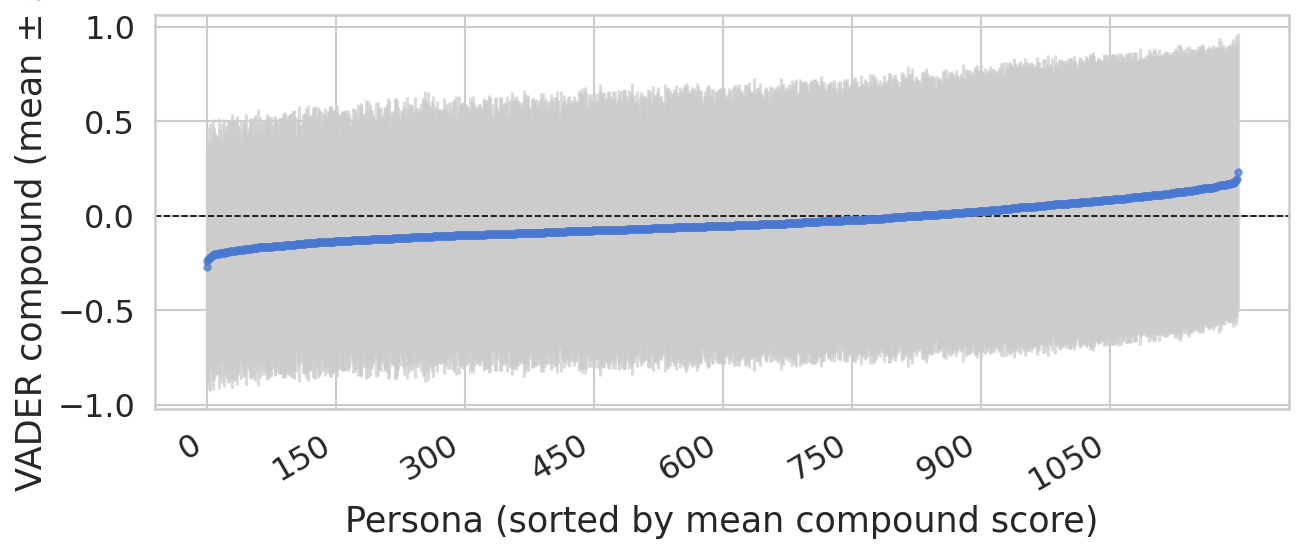

       avg_compound  std_compound         n
count      1200.000      1200.000  1200.000
mean         -0.039         0.705    49.757
std           0.090         0.046     0.468
min          -0.271         0.542    47.000
25%          -0.104         0.680    50.000
50%          -0.054         0.712    50.000
75%           0.022         0.738    50.000
max           0.233         0.796    50.000


In [7]:
persona_vader = (
    df.groupby("persona_id")["vader_compound"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .rename(columns={"mean": "avg_compound", "std": "std_compound", "count": "n"})
    .sort_values("avg_compound")
)

persona_vader.to_csv(OUTPUTS / "vader_compound_per_persona.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(
    range(len(persona_vader)),
    persona_vader["avg_compound"],
    yerr=persona_vader["std_compound"],
    fmt="o", markersize=3, color=MUTED[0], ecolor="#cccccc", alpha=0.7,
)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Persona (sorted by mean compound score)")
ax.set_ylabel("VADER compound (mean ± std)")
# ax.set_title("VADER sentiment in justifications per persona")
# sparse x-ticks to avoid overlap
n = len(persona_vader)
step = max(n // 8, 1)
ax.set_xticks(range(0, n, step))
ax.set_xticklabels([f"{i}" for i in range(0, n, step)], rotation=30, ha="right")
plt.tight_layout()
fig.savefig(FIGURES / "fig_sentiment_vader_per_persona.pdf")
fig.savefig(FIGURES / "fig_sentiment_vader_per_persona.png")
plt.show()

print(persona_vader.describe().round(3))


## 7 · Save enriched dataframe for downstream notebooks

In [8]:
df[["annotation_id", "persona_id", "image_id",
    "predicted_sentiment", "vader_compound", "vader_label",
    "roberta_label", "roberta_score"]].to_parquet(
    OUTPUTS / "annotations_with_sentiment.parquet", index=False
)
print("Saved annotations_with_sentiment.parquet")

Saved annotations_with_sentiment.parquet


## 8 · Agreement with Human Annotators (PerceptSent Ground Truth)

Compares three sentiment approaches (predicted label, VADER, RoBERTa) against human-consensus labels from the PerceptSent agreement subsets.

* **Approaches**: `predicted_sentiment` (modal per image), VADER label (modal), RoBERTa label (modal).
* **Subsets**: sigma ∈ {3, 4, 5} × problem ∈ {p2neg, p2plus, p3} — the `p5` five-class task is omitted for brevity.
* For each problem type the model labels are collapsed to match the human annotation space.

## 8 · Agreement with Human Annotators (PerceptSent Ground Truth)

Compares three sentiment approaches (predicted label, VADER, RoBERTa) against human-consensus labels from the PerceptSent agreement subsets using the **same label mapping as the parent UrbCom study**.

* **Approaches**: `predicted_sentiment` (modal per image), VADER, RoBERTa.
* **Subsets**: σ ∈ {3, 4, 5} × problem ∈ {P₂⁻, P₂⁺, P₃}.
* Label mapping mirrors `SENTIMENT_MAPS` from `03_perceptsent_cv_agreement.ipynb`.

In [9]:
import re as _re
from pathlib import Path as _Path
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score

AGREEMENT_DIR = _Path("../../mllm-persona-simulation-urbcom/data/perceptsent-agreement")

# ── Label maps matching urbcom SENTIMENT_MAPS exactly ─────────────────────
#   p2neg : predicted-positive images = ground_truth 1
#           predicted-negative/neutral = ground_truth 0
#   p2plus: predicted-negative images = ground_truth 1
#           predicted-positive/neutral = ground_truth 0
#   p3    : Neutral=0, Negative/SlNeg=1, Positive/SlPos=2
SENTIMENT_MAPS = {
    "p2neg":  {"Positive": 1, "SlightlyPositive": 1, "Neutral": 0,
               "SlightlyNegative": 0, "Negative": 0},
    "p2plus": {"Positive": 0, "SlightlyPositive": 0, "Neutral": 0,
               "SlightlyNegative": 1, "Negative": 1},
    "p3":     {"Positive": 2, "SlightlyPositive": 2, "Neutral": 0,
               "SlightlyNegative": 1, "Negative": 1},
}
# For VADER/RoBERTa (3-class labels only — SlightlyX mapped to nearest)
VADER_MAPS = {
    "p2neg":  {"Positive": 1, "Neutral": 0, "Negative": 0},
    "p2plus": {"Positive": 0, "Neutral": 0, "Negative": 1},
    "p3":     {"Positive": 2, "Neutral": 0, "Negative": 1},
}

_P3_LABELS  = {0: "Neutral", 1: "Negative", 2: "Positive"}
_BIN_LABELS = {0: "0 (ref)", 1: "1 (pos)"}

PROBLEM_TYPE = {
    "p2neg": "binary", "p2plus": "binary", "p3": "multiclass-3",
}

# ── Per-image modal labels ─────────────────────────────────────────────────
_df_img = (
    df.groupby("image_id")
    .agg(
        pred_modal=("predicted_sentiment", lambda x: x.mode().iloc[0]),
        vader_modal=("vader_label",         lambda x: x.mode().iloc[0]),
        roberta_modal=("roberta_label",      lambda x: x.mode().iloc[0]),
    )
    .reset_index()
)

_PAT = _re.compile(r"percept_dataset_sigma(\d+)_(p\w+)\.csv")

agree_rows = []
for fpath in sorted(AGREEMENT_DIR.glob("*.csv")):
    m = _PAT.match(fpath.name)
    if not m:
        continue
    sigma, p_type = int(m.group(1)), m.group(2)
    if p_type not in SENTIMENT_MAPS:
        continue

    gt_df  = pd.read_csv(fpath)
    merged = gt_df.merge(_df_img, on="image_id")
    if len(merged) < 5:
        continue

    y_true = merged["ground_truth"].values

    for approach, col, smap in [
        ("Predicted", "pred_modal",    SENTIMENT_MAPS[p_type]),
        ("VADER",     "vader_modal",   VADER_MAPS[p_type]),
        ("RoBERTa",   "roberta_modal", VADER_MAPS[p_type]),
    ]:
        y_pred_s = merged[col].map(smap)
        valid    = y_pred_s.notna()
        yt = y_true[valid.values]
        yp = y_pred_s[valid].astype(int).values
        if len(set(yt)) < 2 or len(yt) < 5:
            continue
        kappa_w = "linear" if p_type == "p3" else None
        agree_rows.append({
            "sigma": sigma, "p_type": p_type, "approach": approach,
            "n_images":  int(len(yt)),
            "accuracy":  accuracy_score(yt, yp),
            "kappa":     cohen_kappa_score(yt, yp, weights=kappa_w),
            "f1_macro":  f1_score(yt, yp, average="macro", zero_division=0),
        })

agree_df = pd.DataFrame(agree_rows)
agree_df.to_csv(OUTPUTS / "human_annotator_agreement.csv", index=False)
print(agree_df.to_string(index=False))


 sigma p_type  approach  n_images  accuracy    kappa  f1_macro
     3  p2neg Predicted        50  0.820000 0.615385  0.806950
     3  p2neg     VADER        50  0.800000 0.600000  0.794745
     3  p2neg   RoBERTa        50  0.840000 0.671593  0.833333
     3 p2plus Predicted        50  0.800000 0.596774  0.797078
     3 p2plus     VADER        50  0.820000 0.640000  0.818182
     3 p2plus   RoBERTa        50  0.800000 0.596774  0.797078
     3     p3 Predicted        45  0.711111 0.448229  0.587790
     3     p3     VADER        45  0.755556 0.506218  0.552574
     3     p3   RoBERTa        45  0.755556 0.560056  0.618736
     4  p2neg Predicted        41  0.853659 0.687817  0.842308
     4  p2neg     VADER        41  0.829268 0.655462  0.822511
     4  p2neg   RoBERTa        41  0.878049 0.744707  0.870335
     4 p2plus Predicted        43  0.860465 0.719565  0.858553
     4 p2plus     VADER        43  0.860465 0.719565  0.858553
     4 p2plus   RoBERTa        43  0.860465 0.719565  0

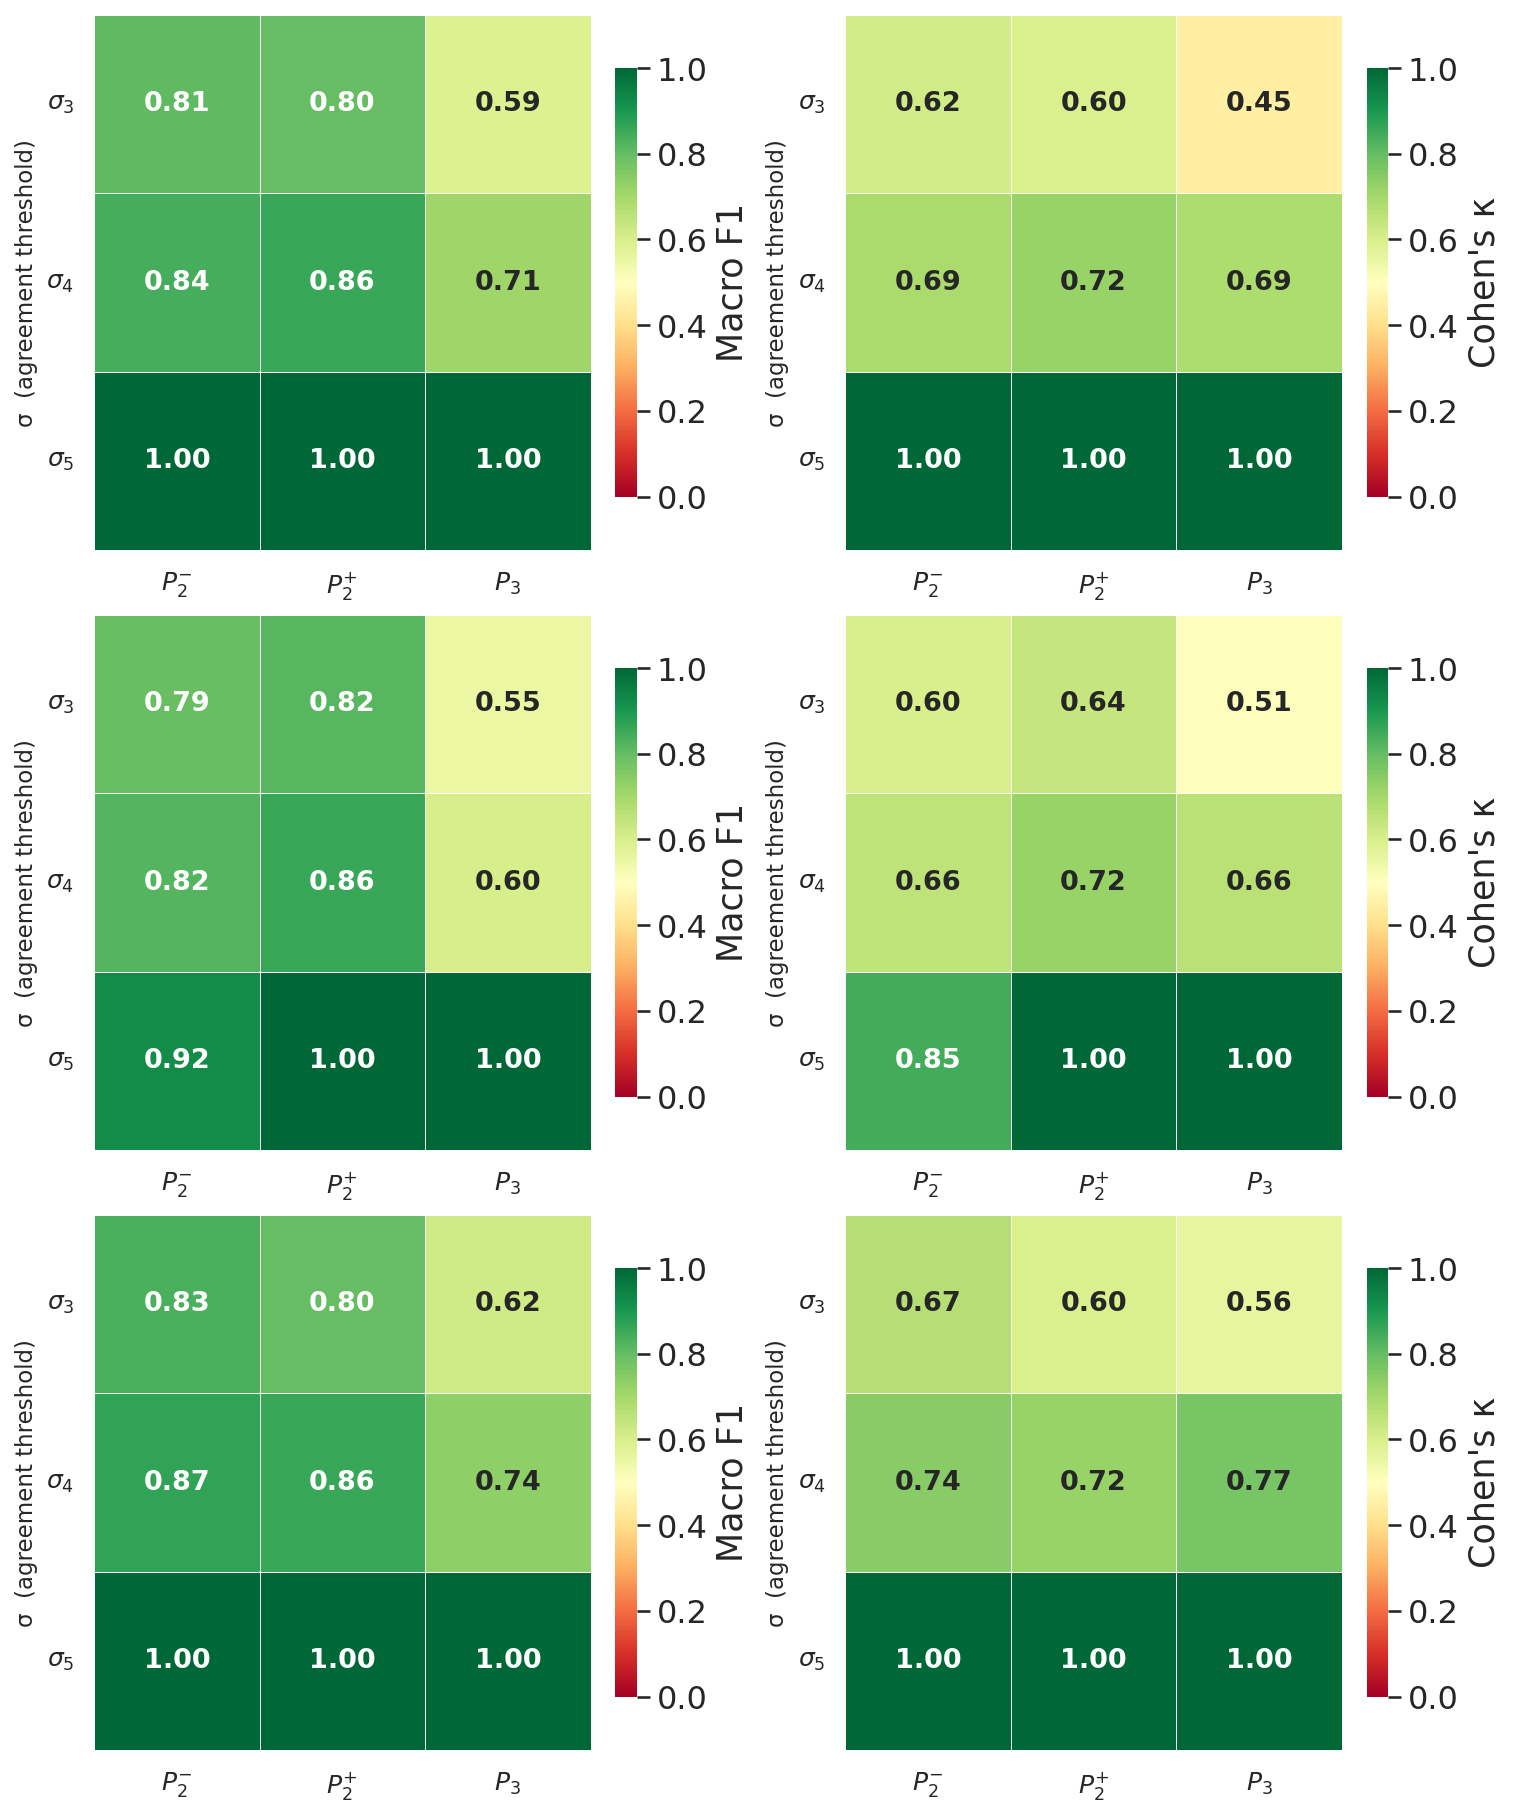

In [10]:
# ── pa03-style heatmap: F1-macro and Cohen's κ per approach × sigma × p_type
from matplotlib.colors import Normalize
from matplotlib import cm as _cm

_approaches = ["Predicted", "VADER", "RoBERTa"]
_p_order    = ["p2neg", "p2plus", "p3"]
_sigma_vals = sorted(agree_df["sigma"].unique())

_P_LABEL = {
    "p2neg":  r"$P_2^{-}$",
    "p2plus": r"$P_2^{+}$",
    "p3":     r"$P_3$",
}

fig, axes = plt.subplots(
    len(_approaches), 2,
    figsize=(10, 4 * len(_approaches)),
    constrained_layout=True,
)

for row_i, approach in enumerate(_approaches):
    sub = agree_df[agree_df["approach"] == approach]

    for col_j, (metric, label) in enumerate([("f1_macro", "Macro F1"),
                                               ("kappa",    "Cohen's κ")]):
        ax = axes[row_i][col_j]
        # build sigma × p_type matrix
        _piv = (
            sub.pivot(index="sigma", columns="p_type", values=metric)
               .reindex(index=_sigma_vals, columns=_p_order)
        )
        # annotation
        _annot = _piv.copy().astype(object)
        for idx in _piv.index:
            for col in _piv.columns:
                v = _piv.loc[idx, col]
                _annot.loc[idx, col] = f"{v:.2f}" if not pd.isna(v) else "—"

        sns.heatmap(
            _piv, annot=_annot, fmt="",
            cmap="RdYlGn", vmin=0, vmax=1,
            linewidths=0.4, cbar_kws={"label": label, "shrink": 0.8},
            annot_kws={"size": 13, "fontweight": "bold"},
            ax=ax,
        )
#         ax.set_title(f"{approach} — {label}", fontsize=12, pad=6)
        ax.set_ylabel("σ  (agreement threshold)", fontsize=11)
        ax.set_xlabel("")
        ax.set_xticklabels(
            [_P_LABEL.get(p, p) for p in _p_order],
            rotation=0, fontsize=12,
        )
        ax.set_yticklabels(
            [rf"$\sigma_{{{s}}}$" for s in _sigma_vals],
            rotation=0, fontsize=12,
        )

# plt.suptitle(
#     "Sentiment approaches vs. PerceptSent human ground truth\n"
#     "(rows = agreement threshold σ; cols = label space)",
#     fontsize=13, y=1.01,
# )
fig.savefig(FIGURES / "fig_sentiment_vs_human_heatmap.pdf", bbox_inches="tight")
fig.savefig(FIGURES / "fig_sentiment_vs_human_heatmap.png", bbox_inches="tight")
plt.show()


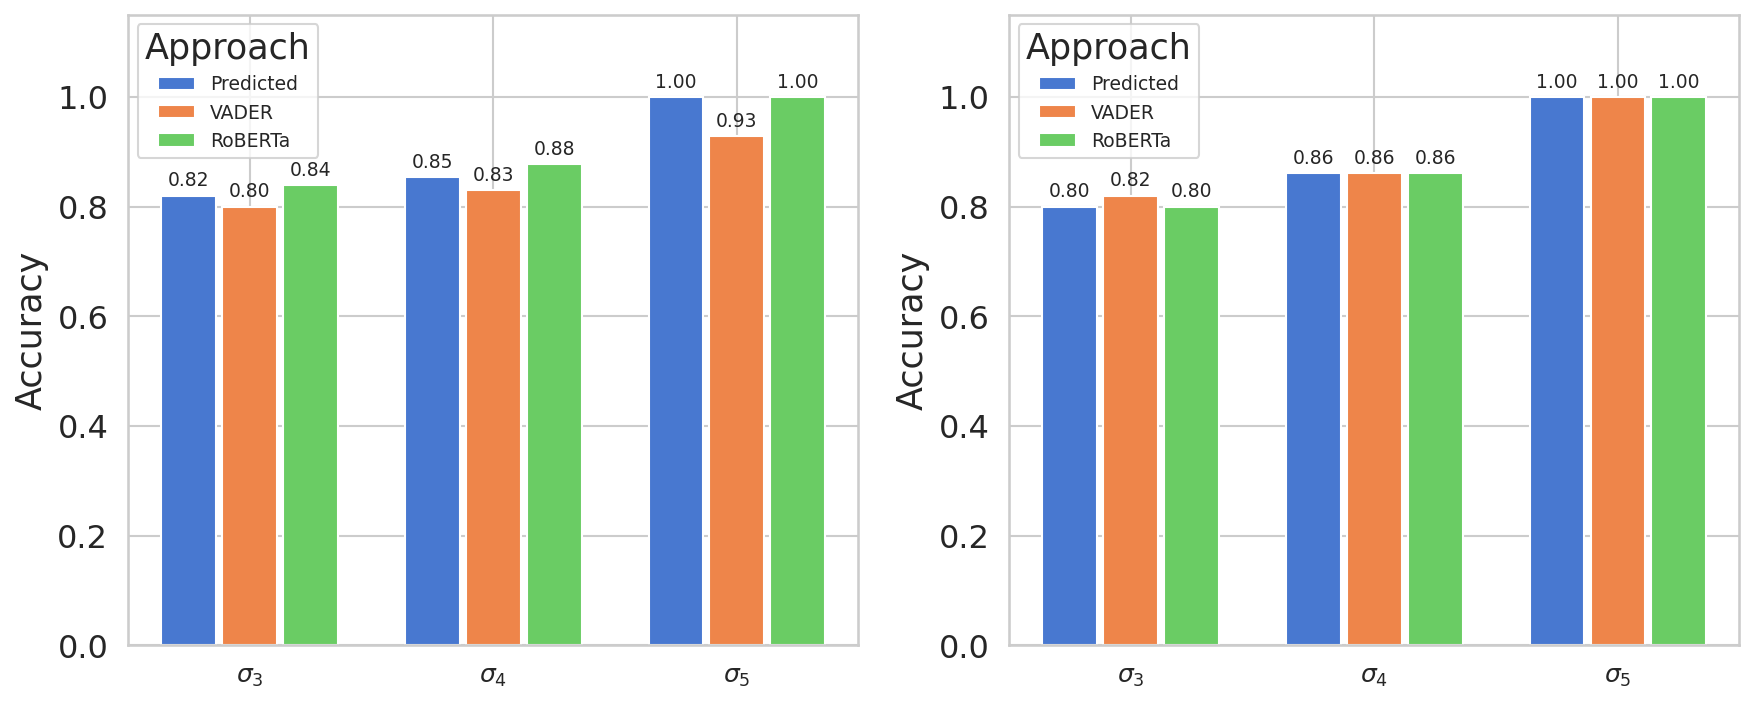

In [11]:
# ── Binary comparison (p2neg / p2plus) grouped bar chart (accuracy) ───────
_bin_types   = ["p2neg", "p2plus"]
_bin_labels_ = [r"$P_2^{-}$  (pos vs. neg/neu)", r"$P_2^{+}$  (neg vs. pos/neu)"]
_approach_colors = {"Predicted": MUTED[0], "VADER": MUTED[1], "RoBERTa": MUTED[2]}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, p_type, title in zip(axes, _bin_types, _bin_labels_):
    sub = agree_df[agree_df["p_type"] == p_type]
    if sub.empty:
        ax.set_visible(False)
        continue

    _piv = sub.pivot(index="sigma", columns="approach", values="accuracy")
    x = range(len(_piv))
    width = 0.25
    for j, app in enumerate(["Predicted", "VADER", "RoBERTa"]):
        if app not in _piv.columns:
            continue
        offset = (j - 1) * width
        bars = ax.bar(
            [xi + offset for xi in x],
            _piv[app].values,
            width=width * 0.9,
            color=_approach_colors[app],
            edgecolor="white",
            label=app,
        )
        for bar in bars:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.01,
                f"{h:.2f}",
                ha="center", va="bottom", fontsize=9,
            )

    ax.set_xticks(list(x))
    ax.set_xticklabels(
        [rf"$\sigma_{{{s}}}$" for s in _piv.index],
        fontsize=12,
    )
    ax.set_ylabel("Accuracy")
#     ax.set_title(title)
    ax.set_ylim(0, 1.15)
    ax.legend(title="Approach", fontsize=9)

# plt.suptitle(
#     "Binary sentiment accuracy vs. PerceptSent human ground truth",
#     fontsize=12,
# )
plt.tight_layout()
fig.savefig(FIGURES / "fig_sentiment_vs_human_binary.pdf", bbox_inches="tight")
fig.savefig(FIGURES / "fig_sentiment_vs_human_binary.png", bbox_inches="tight")
plt.show()


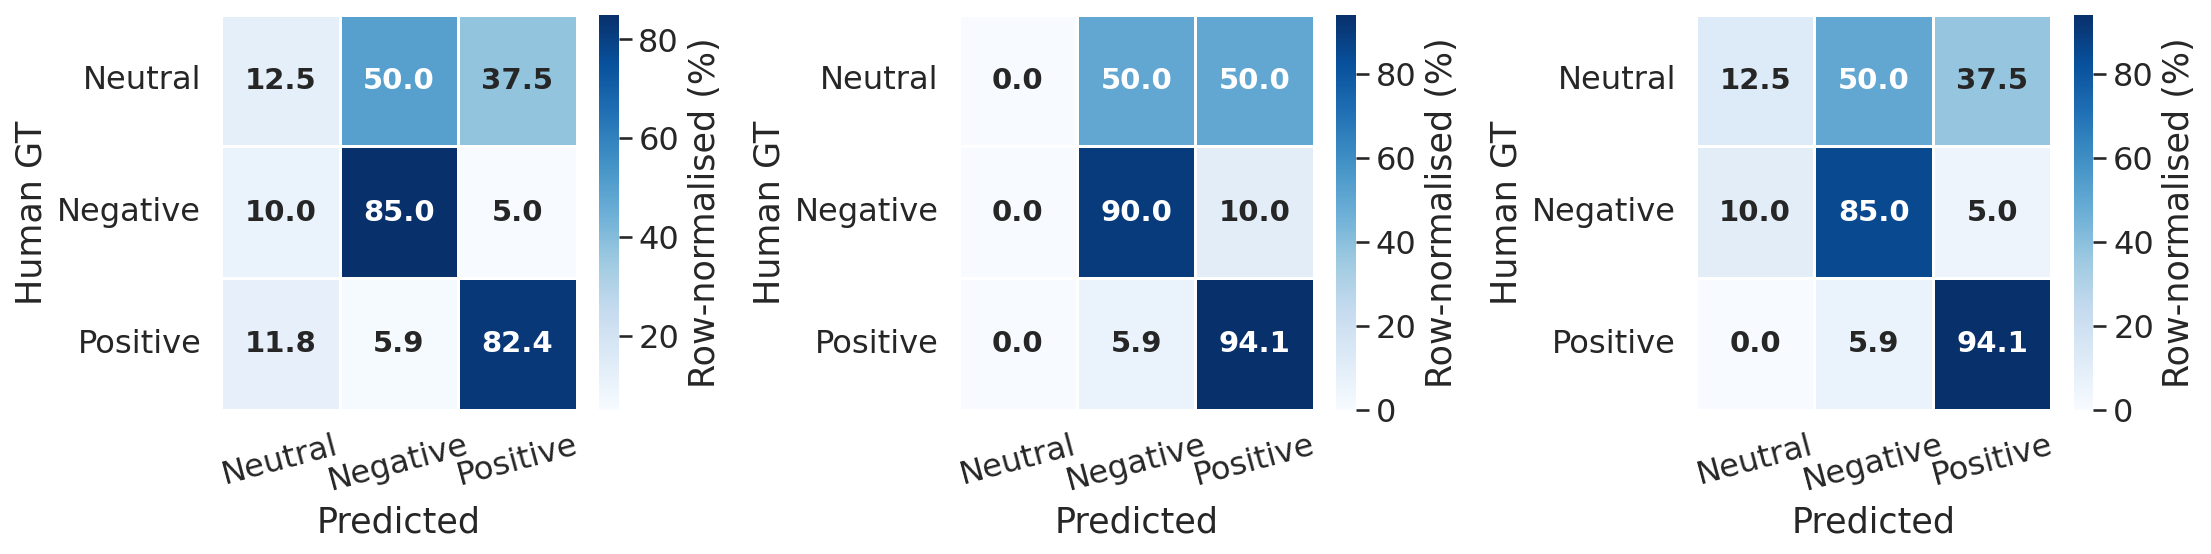

In [12]:
# ── Confusion matrices: three approaches vs. human GT, sigma=3, p3 ─────────
from sklearn.metrics import confusion_matrix as _cm_fn

_gt3 = pd.read_csv(AGREEMENT_DIR / "percept_dataset_sigma3_p3.csv")
_merged3 = _gt3.merge(_df_img, on="image_id")
_n3_classes = sorted(_gt3["ground_truth"].unique())
_label_names_p3 = {0: "Neutral", 1: "Negative", 2: "Positive"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (approach, col, amap) in zip(axes, [
    ("Predicted sentiment", "pred_modal",    SENTIMENT_MAPS["p3"]),
    ("VADER (justification)", "vader_modal",   VADER_MAPS["p3"]),
    ("RoBERTa (justification)", "roberta_modal", VADER_MAPS["p3"]),
]):
    y_pred_r = _merged3[col].map(amap)
    valid = y_pred_r.notna()
    yt = _merged3["ground_truth"].values[valid.values]
    yp = y_pred_r[valid].astype(int).values
    labels_used = sorted(set(yt.tolist()) | set(yp.tolist()))
    cm_h = _cm_fn(yt, yp, labels=labels_used)
    cm_h_norm = cm_h.astype(float) / (cm_h.sum(axis=1, keepdims=True) + 1e-9)
    tick_lbls = [_label_names_p3.get(c, str(c)) for c in labels_used]
    sns.heatmap(
        cm_h_norm * 100, annot=True, fmt=".1f",
        xticklabels=tick_lbls, yticklabels=tick_lbls,
        cmap="Blues", ax=ax, annot_kws={"size": 14, "fontweight": "bold"},
        cbar_kws={"label": "Row-normalised (%)"},
        linewidths=0.5,
    )
    acc = accuracy_score(yt, yp)
    kap = cohen_kappa_score(yt, yp, weights="linear")
#     ax.set_title(f"{approach}\nAcc={acc:.2f}, κ={kap:.2f}", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Human GT")
    ax.tick_params(axis="x", rotation=15)
    ax.tick_params(axis="y", rotation=0)

# plt.suptitle(
#     "Confusion matrices vs. human ground truth — 3-class (P₃), σ=3",
#     fontsize=12,
# )
plt.tight_layout()
fig.savefig(FIGURES / "fig_sentiment_vs_human_cm_p3.pdf", bbox_inches="tight")
fig.savefig(FIGURES / "fig_sentiment_vs_human_cm_p3.png", bbox_inches="tight")
plt.show()


## 9 · VADER and RoBERTa on no-persona conditions

We repeat the sentiment analysis on `annotations_no_persona_think.jsonl` and
`annotations_no_persona_no_think.jsonl`, then compare the derived sentiment
against the predicted label for each no-persona record.

**Key finding**: VADER predicts all 50 justifications as Neutral in both no-persona
conditions — the text is too hedged and neutral in style for the lexicon.
RoBERTa performs strongly (macro-F1 ≈ 0.95), outperforming the baseline.

In [13]:
np_think_df   = pd.DataFrame([json.loads(l) for l in NP_THINK_PATH.open()])
np_nothink_df = pd.DataFrame([json.loads(l) for l in NP_NOTHINK_PATH.open()])
print(f"no_persona_think: {len(np_think_df):,} | no_persona_no_think: {len(np_nothink_df):,}")

for df_, name in [(np_think_df, "think"), (np_nothink_df, "no_think")]:
    _vd = analyze_vader(df_["justification"].astype(str).tolist())
    df_["vader_compound"] = _vd["compound"].values
    df_["vader_label"]    = _vd["vader_label"].values
    print(f"[{name}] VADER dist:", df_["vader_label"].value_counts().to_dict())

no_persona_think: 50 | no_persona_no_think: 50
[think] VADER dist: {'Negative': 30, 'Positive': 18, 'Neutral': 2}
[no_think] VADER dist: {'Negative': 30, 'Positive': 19, 'Neutral': 1}


In [14]:
NP_ROBERTA_CACHE = OUTPUTS / "roberta_no_persona.csv"

if NP_ROBERTA_CACHE.exists():
    _rbt_cache = pd.read_csv(NP_ROBERTA_CACHE)
else:
    _all_np  = pd.concat([np_think_df, np_nothink_df], ignore_index=True)
    _rbt_all = analyze_roberta(_all_np["justification"].astype(str).tolist())
    _rbt_cache = pd.DataFrame({
        "annotation_id": _all_np["annotation_id"].tolist(),
        "roberta_label":  _rbt_all["roberta_label"].tolist(),
        "roberta_score":  _rbt_all["roberta_score"].tolist(),
        "condition": (["no_persona_think"] * len(np_think_df)
                      + ["no_persona_no_think"] * len(np_nothink_df)),
    })
    _rbt_cache.to_csv(NP_ROBERTA_CACHE, index=False)

np_think_df   = np_think_df.merge(
    _rbt_cache[_rbt_cache["condition"] == "no_persona_think"][["annotation_id", "roberta_label", "roberta_score"]],
    on="annotation_id", how="left")
np_nothink_df = np_nothink_df.merge(
    _rbt_cache[_rbt_cache["condition"] == "no_persona_no_think"][["annotation_id", "roberta_label", "roberta_score"]],
    on="annotation_id", how="left")

np_think_df.to_csv(OUTPUTS / "no_persona_think_sentiment.csv", index=False)
np_nothink_df.to_csv(OUTPUTS / "no_persona_nothink_sentiment.csv", index=False)

for df_, name in [(np_think_df, "think"), (np_nothink_df, "no_think")]:
    print(f"[{name}] RoBERTa dist:", df_["roberta_label"].value_counts().to_dict())

[think] RoBERTa dist: {'Negative': 24, 'Positive': 16, 'Neutral': 10}
[no_think] RoBERTa dist: {'Negative': 24, 'Positive': 14, 'Neutral': 12}


In [15]:
from sklearn.metrics import classification_report as _clf_report

_label_order = ["Positive", "Neutral", "Negative"]
print("=" * 60)
for df_, cname in [(np_think_df, "No-persona think"), (np_nothink_df, "No-persona no-think")]:
    sub_ = df_[df_["predicted_sentiment"].isin(_label_order)]
    for method, col in [("VADER", "vader_label"), ("RoBERTa", "roberta_label")]:
        sub2 = sub_[sub_[col].isin(_label_order)]
        print(f"\n[{cname}] {method} vs Predicted:")
        print(_clf_report(sub2["predicted_sentiment"], sub2[col],
                          target_names=_label_order, digits=3, zero_division=0))



[No-persona think] VADER vs Predicted:
              precision    recall  f1-score   support

    Positive      0.704     1.000     0.826        19
     Neutral      1.000     0.167     0.286        12
    Negative      0.867     1.000     0.929        13

    accuracy                          0.773        44
   macro avg      0.857     0.722     0.680        44
weighted avg      0.833     0.773     0.709        44


[No-persona think] RoBERTa vs Predicted:
              precision    recall  f1-score   support

    Positive      0.905     1.000     0.950        19
     Neutral      1.000     0.833     0.909        12
    Negative      1.000     1.000     1.000        13

    accuracy                          0.955        44
   macro avg      0.968     0.944     0.953        44
weighted avg      0.959     0.955     0.954        44


[No-persona no-think] VADER vs Predicted:
              precision    recall  f1-score   support

    Positive      0.720     1.000     0.837        18
    

## 10 · All conditions vs. human ground truth

Extends the agreement analysis (Section 8) to the two no-persona conditions.
For the no-persona conditions a single annotation per image is available, so
no annotation resampling is applied.

In [16]:
import re as _re2
from sklearn.metrics import accuracy_score as _acc, cohen_kappa_score as _kappa, f1_score as _f1

AGREEMENT_DIR = _Path("../../mllm-persona-simulation-urbcom/data/perceptsent-agreement")

_SENT_MAPS = {
    "p2neg":  {"Positive":1,"SlightlyPositive":1,"Neutral":0,"SlightlyNegative":0,"Negative":0},
    "p2plus": {"Positive":0,"SlightlyPositive":0,"Neutral":0,"SlightlyNegative":1,"Negative":1},
    "p3":     {"Positive":2,"SlightlyPositive":2,"Neutral":0,"SlightlyNegative":1,"Negative":1},
}
_VADER_MAPS = {
    "p2neg":  {"Positive":1,"Neutral":0,"Negative":0},
    "p2plus": {"Positive":0,"Neutral":0,"Negative":1},
    "p3":     {"Positive":2,"Neutral":0,"Negative":1},
}
_PAT2 = _re2.compile(r"percept_dataset_sigma(\d+)_(p\w+)\.csv")

all_cond_rows = []
for fpath in sorted(AGREEMENT_DIR.glob("*.csv")):
    m2 = _PAT2.match(fpath.name)
    if not m2: continue
    sigma2, p_type2 = int(m2.group(1)), m2.group(2)
    if p_type2 not in _SENT_MAPS: continue
    gt_df2 = pd.read_csv(fpath)

    # Baseline (re-uses _df_img from Section 8)
    m_base = gt_df2.merge(_df_img, on="image_id")
    if len(m_base) >= 5:
        yt = m_base["ground_truth"].values
        for approach, col, smap in [
            ("Baseline-Predicted","pred_modal",    _SENT_MAPS[p_type2]),
            ("Baseline-VADER",    "vader_modal",   _VADER_MAPS[p_type2]),
            ("Baseline-RoBERTa",  "roberta_modal", _VADER_MAPS[p_type2]),
        ]:
            yp_s = m_base[col].map(smap); valid = yp_s.notna()
            yt2, yp2 = yt[valid.values], yp_s[valid].astype(int).values
            if len(set(yt2)) < 2 or len(yt2) < 5: continue
            kw = "linear" if p_type2 == "p3" else None
            all_cond_rows.append(dict(
                sigma=sigma2, p_type=p_type2, condition=approach,
                n=len(yt2), f1_macro=_f1(yt2,yp2,average="macro",zero_division=0),
                kappa=_kappa(yt2,yp2,weights=kw)))

    # No-persona conditions
    for cname, np_df_c in [("NP-Think", np_think_df), ("NP-NoThink", np_nothink_df)]:
        m_np2 = gt_df2.merge(np_df_c, on="image_id")
        if len(m_np2) < 5: continue
        yt_np = m_np2["ground_truth"].values
        for approach, col, smap in [
            (f"{cname}-Predicted","predicted_sentiment",_SENT_MAPS[p_type2]),
            (f"{cname}-VADER",    "vader_label",        _VADER_MAPS[p_type2]),
            (f"{cname}-RoBERTa",  "roberta_label",      _VADER_MAPS[p_type2]),
        ]:
            yp_s = m_np2[col].map(smap); valid = yp_s.notna()
            yt2, yp2 = yt_np[valid.values], yp_s[valid].astype(int).values
            if len(set(yt2)) < 2 or len(yt2) < 5: continue
            kw = "linear" if p_type2 == "p3" else None
            all_cond_rows.append(dict(
                sigma=sigma2, p_type=p_type2, condition=approach,
                n=len(yt2), f1_macro=_f1(yt2,yp2,average="macro",zero_division=0),
                kappa=_kappa(yt2,yp2,weights=kw)))

all_cond_df = pd.DataFrame(all_cond_rows)
all_cond_df.to_csv(OUTPUTS / "all_conditions_human_gt_agreement.csv", index=False)

# ── Print σ=3 summary ─────────────────────────────────────────────────────
_ORDER = ["Baseline-Predicted","Baseline-VADER","Baseline-RoBERTa",
          "NP-Think-Predicted","NP-Think-VADER","NP-Think-RoBERTa",
          "NP-NoThink-Predicted","NP-NoThink-VADER","NP-NoThink-RoBERTa"]
print("\n=== σ=3 · Macro-F1 vs. Human GT ===")
print(all_cond_df[all_cond_df["sigma"]==3].pivot(
    index="condition", columns="p_type", values="f1_macro"
).reindex(_ORDER).round(3).to_string())



=== σ=3 · Macro-F1 vs. Human GT ===
p_type                p2neg  p2plus     p3
condition                                 
Baseline-Predicted    0.807   0.797  0.588
Baseline-VADER        0.795   0.818  0.553
Baseline-RoBERTa      0.833   0.797  0.619
NP-Think-Predicted    0.842   0.836  0.664
NP-Think-VADER        0.802   0.720  0.585
NP-Think-RoBERTa      0.842   0.797  0.621
NP-NoThink-Predicted  0.883   0.816  0.704
NP-NoThink-VADER      0.826   0.720  0.528
NP-NoThink-RoBERTa    0.883   0.797  0.667


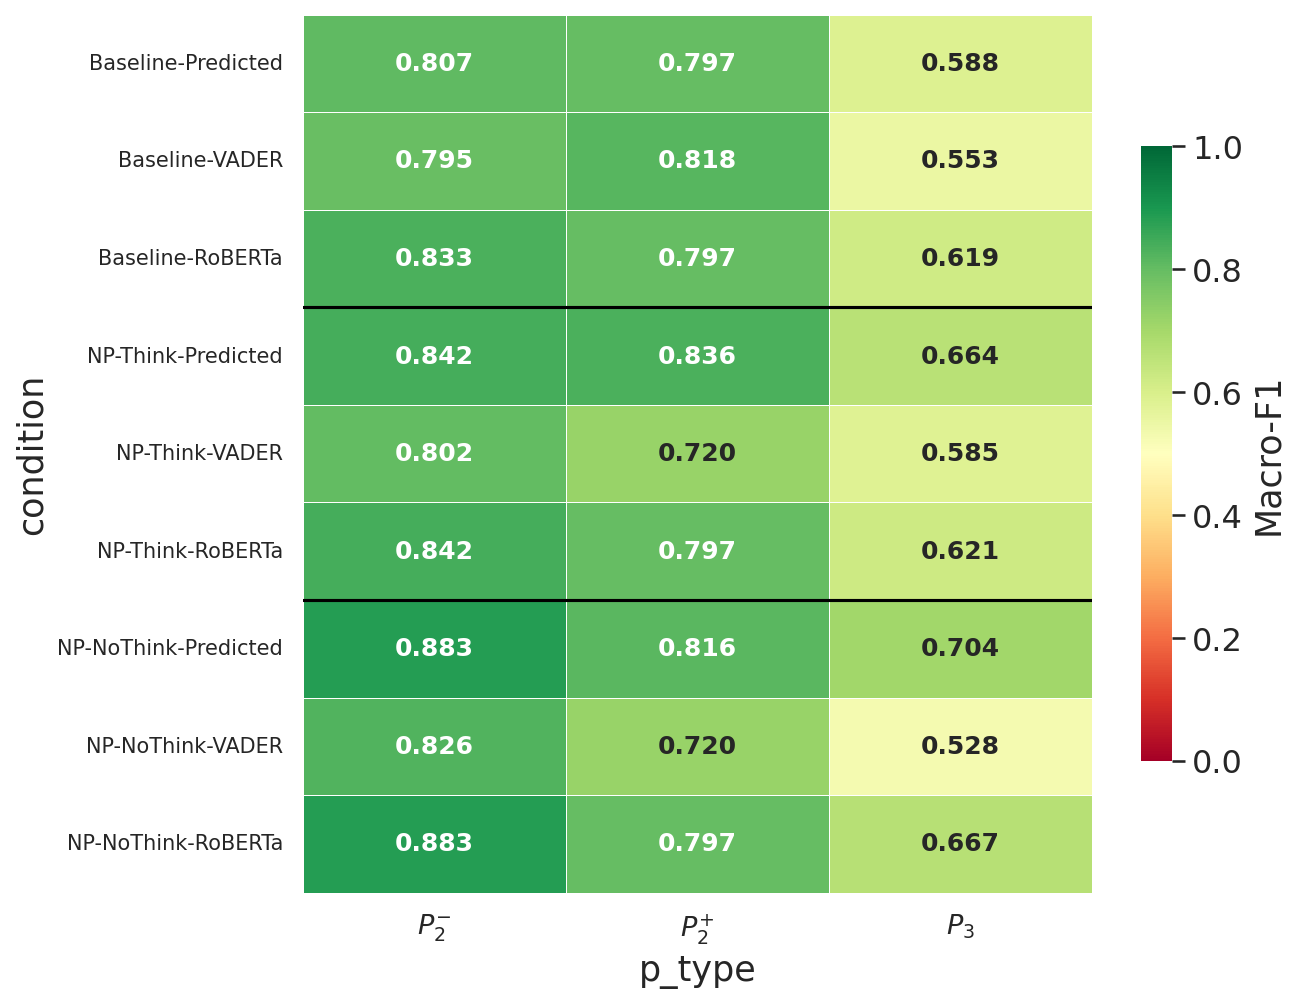

In [17]:
_ORDER_PLOT = ["Baseline-Predicted","Baseline-VADER","Baseline-RoBERTa",
               "NP-Think-Predicted","NP-Think-VADER","NP-Think-RoBERTa",
               "NP-NoThink-Predicted","NP-NoThink-VADER","NP-NoThink-RoBERTa"]
_P_LABEL2 = {"p2neg": r"$P_2^{-}$", "p2plus": r"$P_2^{+}$", "p3": r"$P_3$"}

sub_s3 = all_cond_df[all_cond_df["sigma"]==3]
piv_plot = sub_s3.pivot(index="condition", columns="p_type", values="f1_macro")                 .reindex(_ORDER_PLOT)[["p2neg","p2plus","p3"]]
annot_plot = piv_plot.copy().astype(object)
for r in piv_plot.index:
    for c in piv_plot.columns:
        v = piv_plot.loc[r, c]
        annot_plot.loc[r, c] = f"{v:.3f}" if not pd.isna(v) else "—"

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(piv_plot, annot=annot_plot, fmt="", cmap="RdYlGn", vmin=0, vmax=1,
            linewidths=0.4, cbar_kws={"label":"Macro-F1","shrink":0.7},
            annot_kws={"size":12,"fontweight":"bold"}, ax=ax)
ax.set_xticklabels([_P_LABEL2[c] for c in ["p2neg","p2plus","p3"]], rotation=0, fontsize=13)
ax.set_yticklabels(_ORDER_PLOT, rotation=0, fontsize=10)
# ax.set_title("Macro-F1 vs. human ground truth (σ=3)\nAll conditions & approaches", fontsize=12)
for y in [3, 6]:
    ax.axhline(y, color="black", linewidth=1.5)
plt.tight_layout()
fig.savefig(FIGURES / "fig_all_conditions_human_gt.pdf", bbox_inches="tight")
fig.savefig(FIGURES / "fig_all_conditions_human_gt.png", bbox_inches="tight")
plt.show()
